In [2]:
from qsopt import * 
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import qutip

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")

JAX version: 0.9.2
QuTiP version: 5.2.2


## Define experimental parameters

In [3]:
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 1

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = inverse_pulse_width      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, 0.0, 8.0])/inverse_pulse_width) 
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.0001,  
    dephasing = 0.0001,      
    relaxation = 0.0001
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Number of qubits:          1
  Cavity levels:             2
  Qubit levels:         [2]
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                  [7.5]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   None
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      3
  Measurement times:    [-8.0, 0.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0001]
  Dephasing rate:       [0.0001]
  Relaxation rate:      [0.0001]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: results/pulse_shape.png


C:\Users\natth\AppData\Local\Temp\ipykernel_6504\2894009835.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


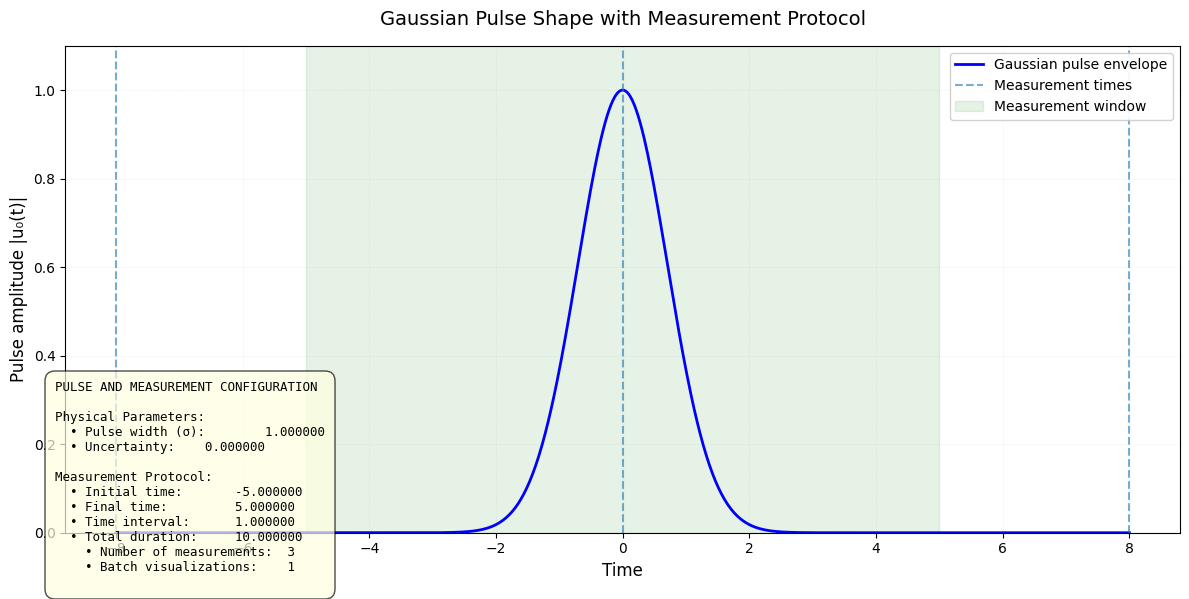

In [4]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=1
)
fig.show()

## Define quantum circuits

The interface uses `QuantumCircuit` objects to define the gates applied before and after evolution.

In [5]:
from qsopt.core.circuit import create_ry_circuit
initial_circuit = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])#, trainable=False)
final_circuit = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])

# The circuits contain trainable parameters that will be optimized
print(f"Initial circuit parameters: {initial_circuit.get_trainable_parameters()}")
print(initial_circuit)
print(f"Final circuit parameters: {final_circuit.get_trainable_parameters()}")
print(final_circuit)

Initial circuit parameters: [Array(1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=1.571)
Final circuit parameters: [Array(-1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=-1.571)


## Define experiment

In [6]:
detection_metric = DetectionMetric(n_qubits=1, 
                                   detection_criterion = 'max computational distance', 
                                   detection_param=(lambda x, y: jnp.power(x - y, 2), 1.0))

print(detection_metric)

experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
    detection_metric=detection_metric
)


DetectionMetric: max computational distance with computational distance
detection criterion:
  'max computational distance'
metric:
  'computational distance'
batching logic:
  'max computational distance batching'
multiple measurement logic:
  'list aggregation'



## Test Single Simulation

In [7]:
results = experiment.run_simulation(debug=False)
print(results)

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.249543
     Without photon: 0.000000
     Metric:            0.249543


## Time Evolution

In [8]:
'''result = experiment.time_evolution(n_points=300, with_interaction=True)
print(result)

from qsopt.utils.visualization import plot_time_evolution
plot_time_evolution(
    evolution_data=result,
    show_pulse=True,
    show_measurements=True,
    show_cavity_population=True,  # Cavity population (purple)
    show_field_population=True,   # External field population (brown)
    title='Single Qubit Evolution',
    figsize=(10, 6)
)
plt.show()'''

"result = experiment.time_evolution(n_points=300, with_interaction=True)\nprint(result)\n\nfrom qsopt.utils.visualization import plot_time_evolution\nplot_time_evolution(\n    evolution_data=result,\n    show_pulse=True,\n    show_measurements=True,\n    show_cavity_population=True,  # Cavity population (purple)\n    show_field_population=True,   # External field population (brown)\n    title='Single Qubit Evolution',\n    figsize=(10, 6)\n)\nplt.show()"

## Run Optimization

In [9]:
import optax

# Use an explicit callback so this history is not overwritten by later optimizations
history_callback = OptimizationCallback(save_every=1, save_best=True)

history = experiment.optimize_rotations(
    initial_values=[1, -0.8], 
    num_steps=1,
    verbose=True,
    verbose_step=50,
    batch_size=1,
    tolerance=1e-7,
    callback=history_callback,
    optimizer=optax.sgd(learning_rate=0.05)
)

Configuration:
    Max iterations: 1
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection metric: max computational distance with computational distance
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.000  rad (57.3°)
        param1.  reset_RY[0]  = -0.800 rad (-45.8°)
Step  setup0_RY[0]   reset0_RY[0]   Metric      Grad Norm   Time
---------------------------------------------------------------------
0     1.300000       -1.000000      -0.569225   2.82e-01    00h00m27s
1     1.313449       -1.004293      -0.565262   2.79e-01    00h00m27s
2     1.326796       -1.008355      -0.561392   2.76e-01    00h00m28s
50    1.816663       -1.017227      -0.455953   1.34e-01    00h00m46s
100   2.003467       -0.991591      -0.439690   3.50e-02    00h01m05s
150   2.054793       -1.009586      -0.438405   1.39e-02    00h01m24s
200   2.074463       -1.025936      -0.438136   7.28e-03    00h01m43s
Final gr

In [10]:
print(history)

MODE: Optimization
     Total iterations: 1
     Best epoch:        1
     Converged: False
     Final gradient norm: 2.117289e-01
  Best Parameters:
     Initial circuit:
        param_0: 1.000000 rad (57.30°)
     Final circuit:
        param_0: -0.800000 rad (-45.84°)
  Detection Measures:
     With photon:    0.090927
     Without photon: 0.000000
     Metric:            0.090927


/raid/home/ncampioni/Quantum-sensing-QML/src/qsopt/utils/visualization.py:340: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


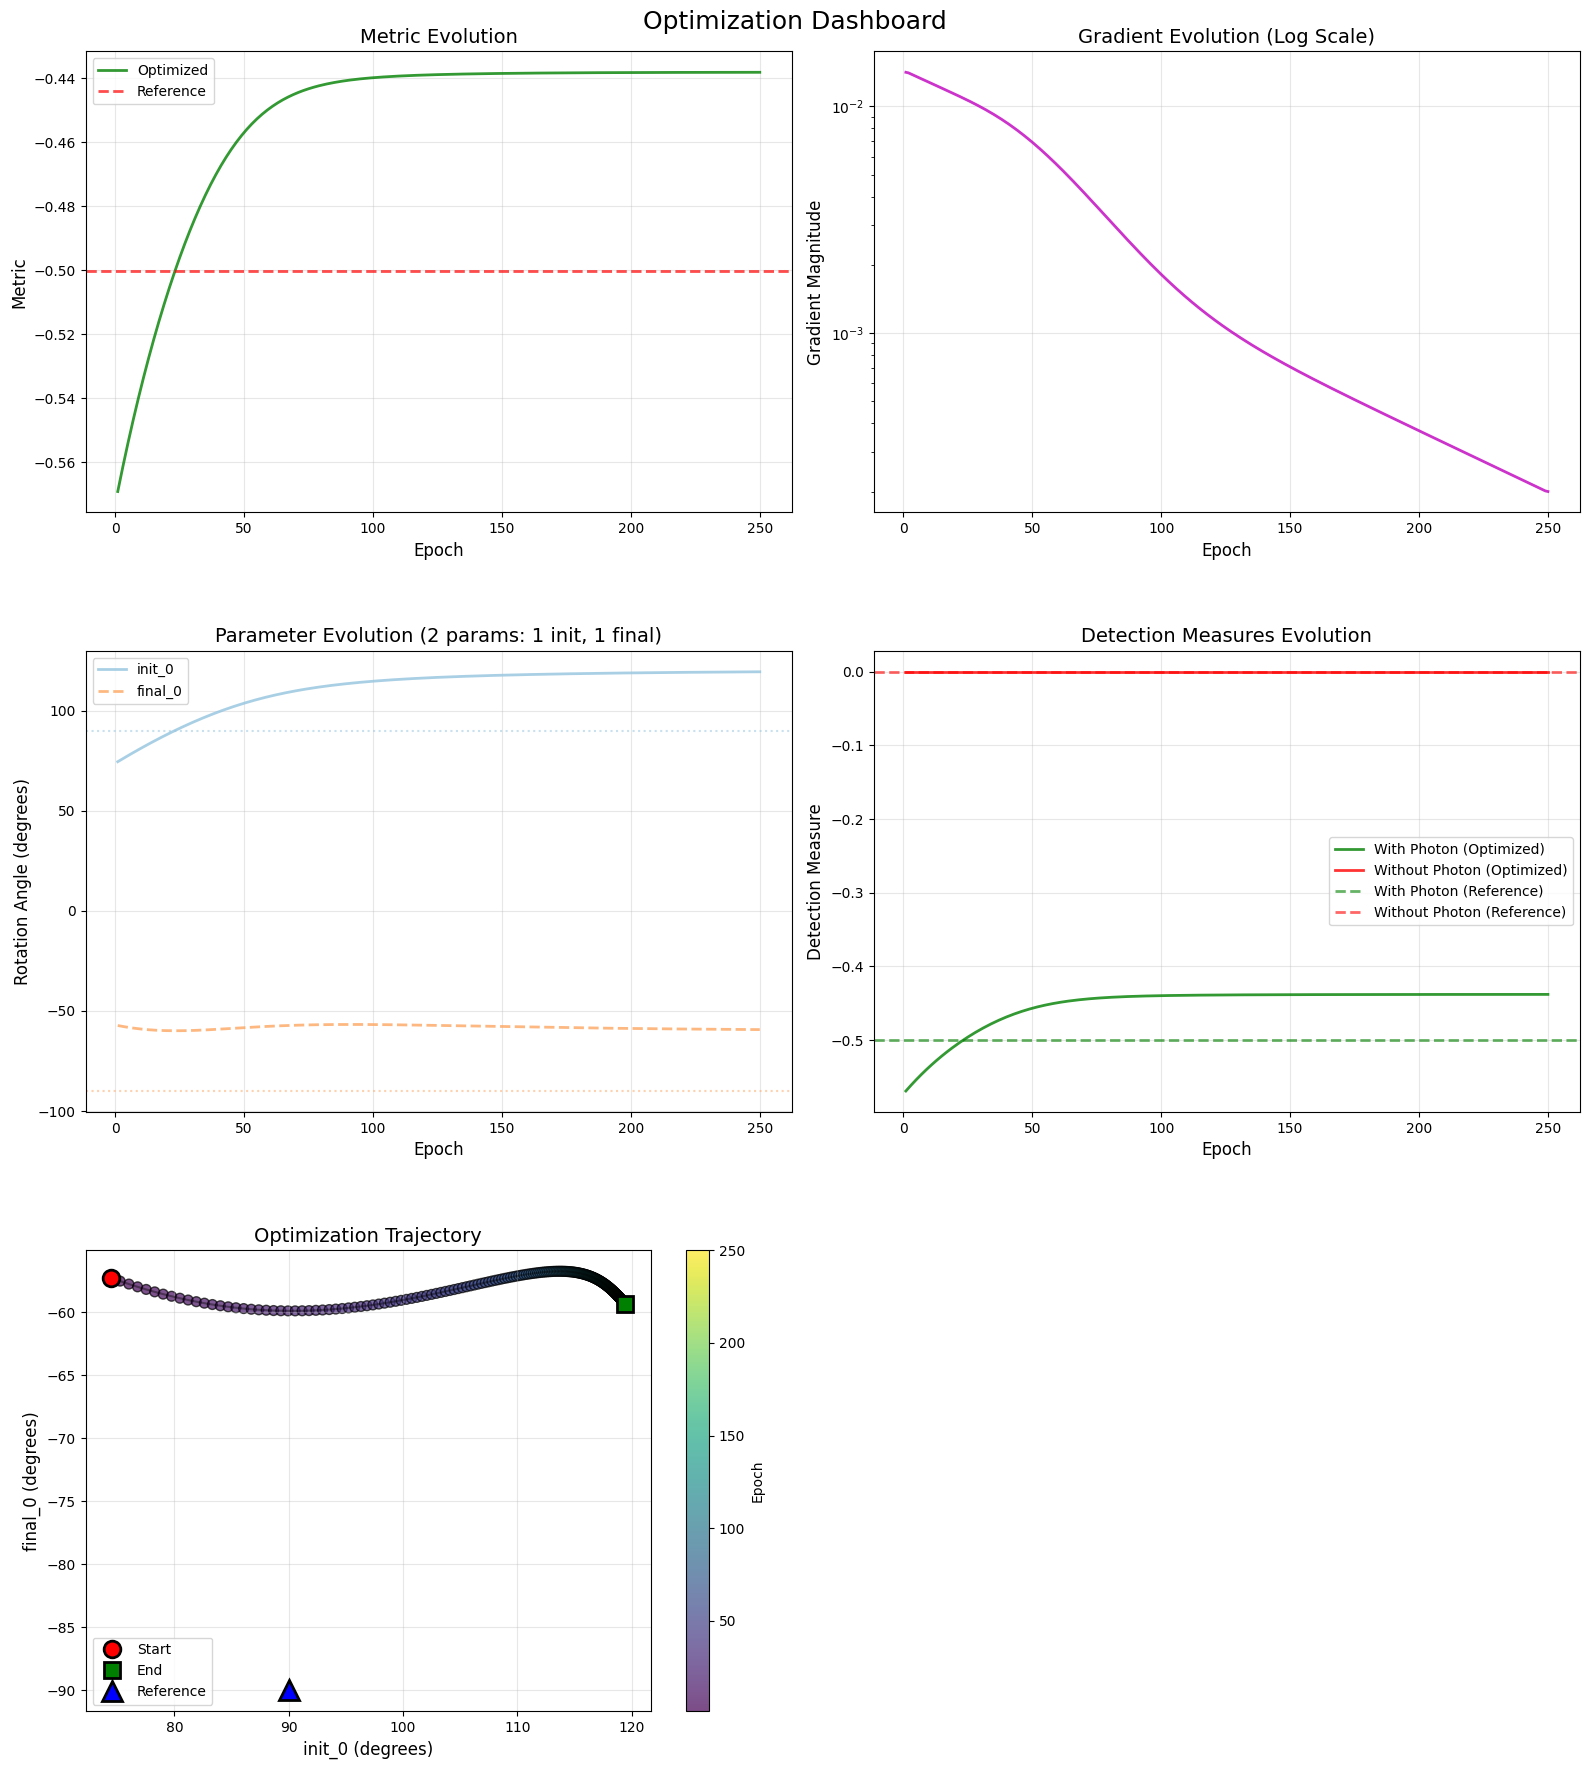

In [11]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times

In [12]:
# time_callback = experiment.optimize_measurement_times(batch_size=1, mode='discrete', verbose=True)

In [13]:
# from qsopt.utils.visualization import plot_time_interval_landscape

# fig = plot_time_interval_landscape(
#     landscape_data=time_callback,
#     exp_params=experiment.experimental_params,
#     save_path='results/time_interval_opt.pdf'
# )


## Sweep chi-gamma

In [14]:
results_sweep = experiment.sweep_chi_gamma(
    chi_interval=[1.0, 30.0],
    gamma_interval=[1.0, 60.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [1.00, 30.00] (linear scale)
  γ range: [1.00, 60.00] (linear scale)
  Progress: 10.0% | Elapsed: 60.1s
  Progress: 20.0% | Elapsed: 121.3s
  Progress: 30.0% | Elapsed: 185.1s
  Progress: 40.0% | Elapsed: 248.8s
  Progress: 50.0% | Elapsed: 313.0s
  Progress: 60.0% | Elapsed: 369.8s


KeyboardInterrupt: 

SweepResults:
  Parameter 1: gamma
    Interval: [1, 60]
    Scale: linear
    Resolution: 10 points
  Parameter 2: chi
    Interval: [1, 30]
    Scale: linear
    Resolution: 10 points
  Available results: detection_map, detection_without_map, metric_map
  Optimal point: chi=4.22, gamma=7.56


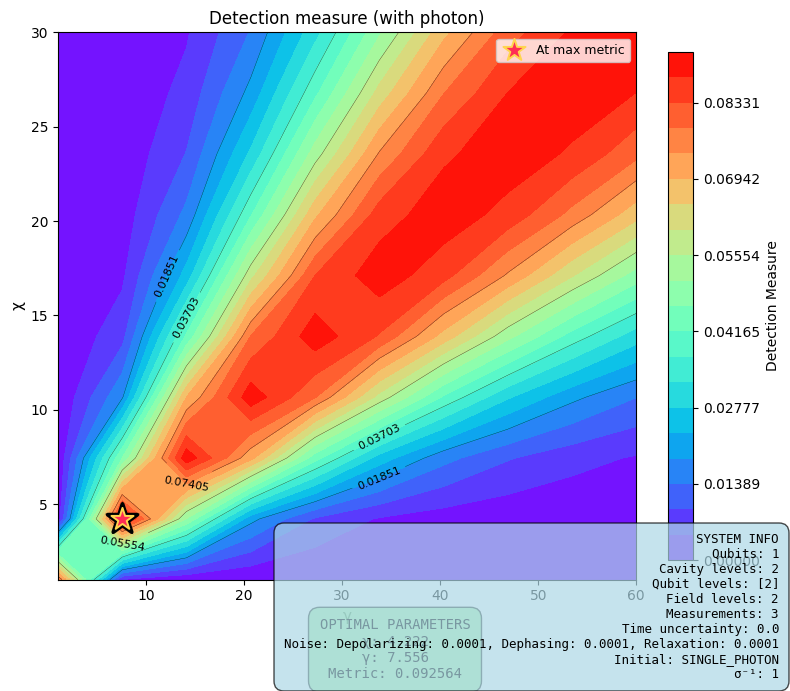

In [24]:
from qsopt.utils.visualization import plot_sweep_results

print(results_sweep)

plot_sweep_results(
    results_sweep,
    results_to_plot=['detection_map'],
    figsize=(8, 7)
)
plt.show()

## Continue Optimization From a Saved Callback

You can stop and resume optimization by saving the callback to disk and loading it back with `OptimizationCallback.load_callback`.
This restores both parameters and optimizer state (and gradients), so `hot_start=True` continues from the saved point.

In [25]:
history.save('results/single_qubit_hotstart.npz')

loaded_history = OptimizationCallback.load_callback('results/single_qubit_hotstart.npz')

history_resumed = experiment.optimize_rotations(
    num_steps=10,
    batch_size=1,
    verbose=True,
    verbose_step=1,
    tolerance=1e-7,
    callback=loaded_history,
    optimizer=optax.sgd(learning_rate=0.5),
    hot_start=True,
)

print(history_resumed)

print('\n' + '-' * 80 + '\n')

# Build a fresh experiment for a clean 15-step baseline from the same initial values
baseline_experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=create_ry_circuit(n_qubits=1, theta_values=[np.pi / 2]),
    final_circuit=create_ry_circuit(n_qubits=1, theta_values=[-np.pi / 2]),
    detection_metric=detection_metric,
 )

continued_callback = OptimizationCallback(save_every=1, save_best=True)
history_continued = baseline_experiment.optimize_rotations(
    initial_values=[1.3, -1.0], 
    num_steps=15,
    verbose=True,
    verbose_step=1,
    batch_size=1,
    tolerance=1e-7,
    callback=continued_callback,
    optimizer=optax.sgd(learning_rate=0.5)
)

print(history_continued)

m_resumed = np.array(history_resumed.history['metric'], dtype=float)
m_continued = np.array(history_continued.history['metric'], dtype=float)
n_overlap = min(len(m_resumed), len(m_continued))
print(f'len(resumed)={len(m_resumed)}, len(continued)={len(m_continued)}')
print('max_abs_metric_diff_on_overlap=', float(np.max(np.abs(m_resumed[:n_overlap] - m_continued[:n_overlap]))))

Starting hot start optimization, trying to load last parameters, optimizer state, and gradients from callback:
- Parameters LOADED
- Gradients LOADED
- Optimizer state LOADED
Resuming from epoch 1, running until epoch 11
Configuration:
    Max iterations: 11
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection metric: max computational distance with computational distance
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.058  rad (60.6°)
        param1.  reset_RY[0]  = -0.888 rad (-50.9°)
Step  setup0_RY[0]   reset0_RY[0]   Metric      Grad Norm   Time
---------------------------------------------------------------------


1     1.058384       -0.888310      0.114150    2.26e-01    00h00m12s
2     1.122597       -0.981089      0.139999    2.31e-01    00h00m13s
3     1.189914       -1.074767      0.166344    2.24e-01    00h00m14s
4     1.256524       -1.164786      0.190492    2.05e-01    00h00m15s
5     1.318443       -1.246678      0.210254    1.78e-01    00h00m16s
6     1.372657       -1.317316      0.224789    1.47e-01    00h00m17s
7     1.417789       -1.375548      0.234572    1.18e-01    00h00m18s
8     1.453963       -1.421939      0.240738    9.17e-02    00h00m19s
9     1.482218       -1.458042      0.244456    7.04e-02    00h00m20s
10    1.503928       -1.485723      0.246636    5.35e-02    00h00m21s
Final gradient norm: 5.35e-02
Best metric: 0.246636
Best parameters:
    param0. setup_RY[0](param=1.504)=1.504 rad (86.2°)
    param1. reset_RY[0](param=-1.486)=-1.486 rad (-85.1°)
MODE: Optimization
     Total iterations: 11
     Best epoch:        11
     Converged: False
     Final gradient norm

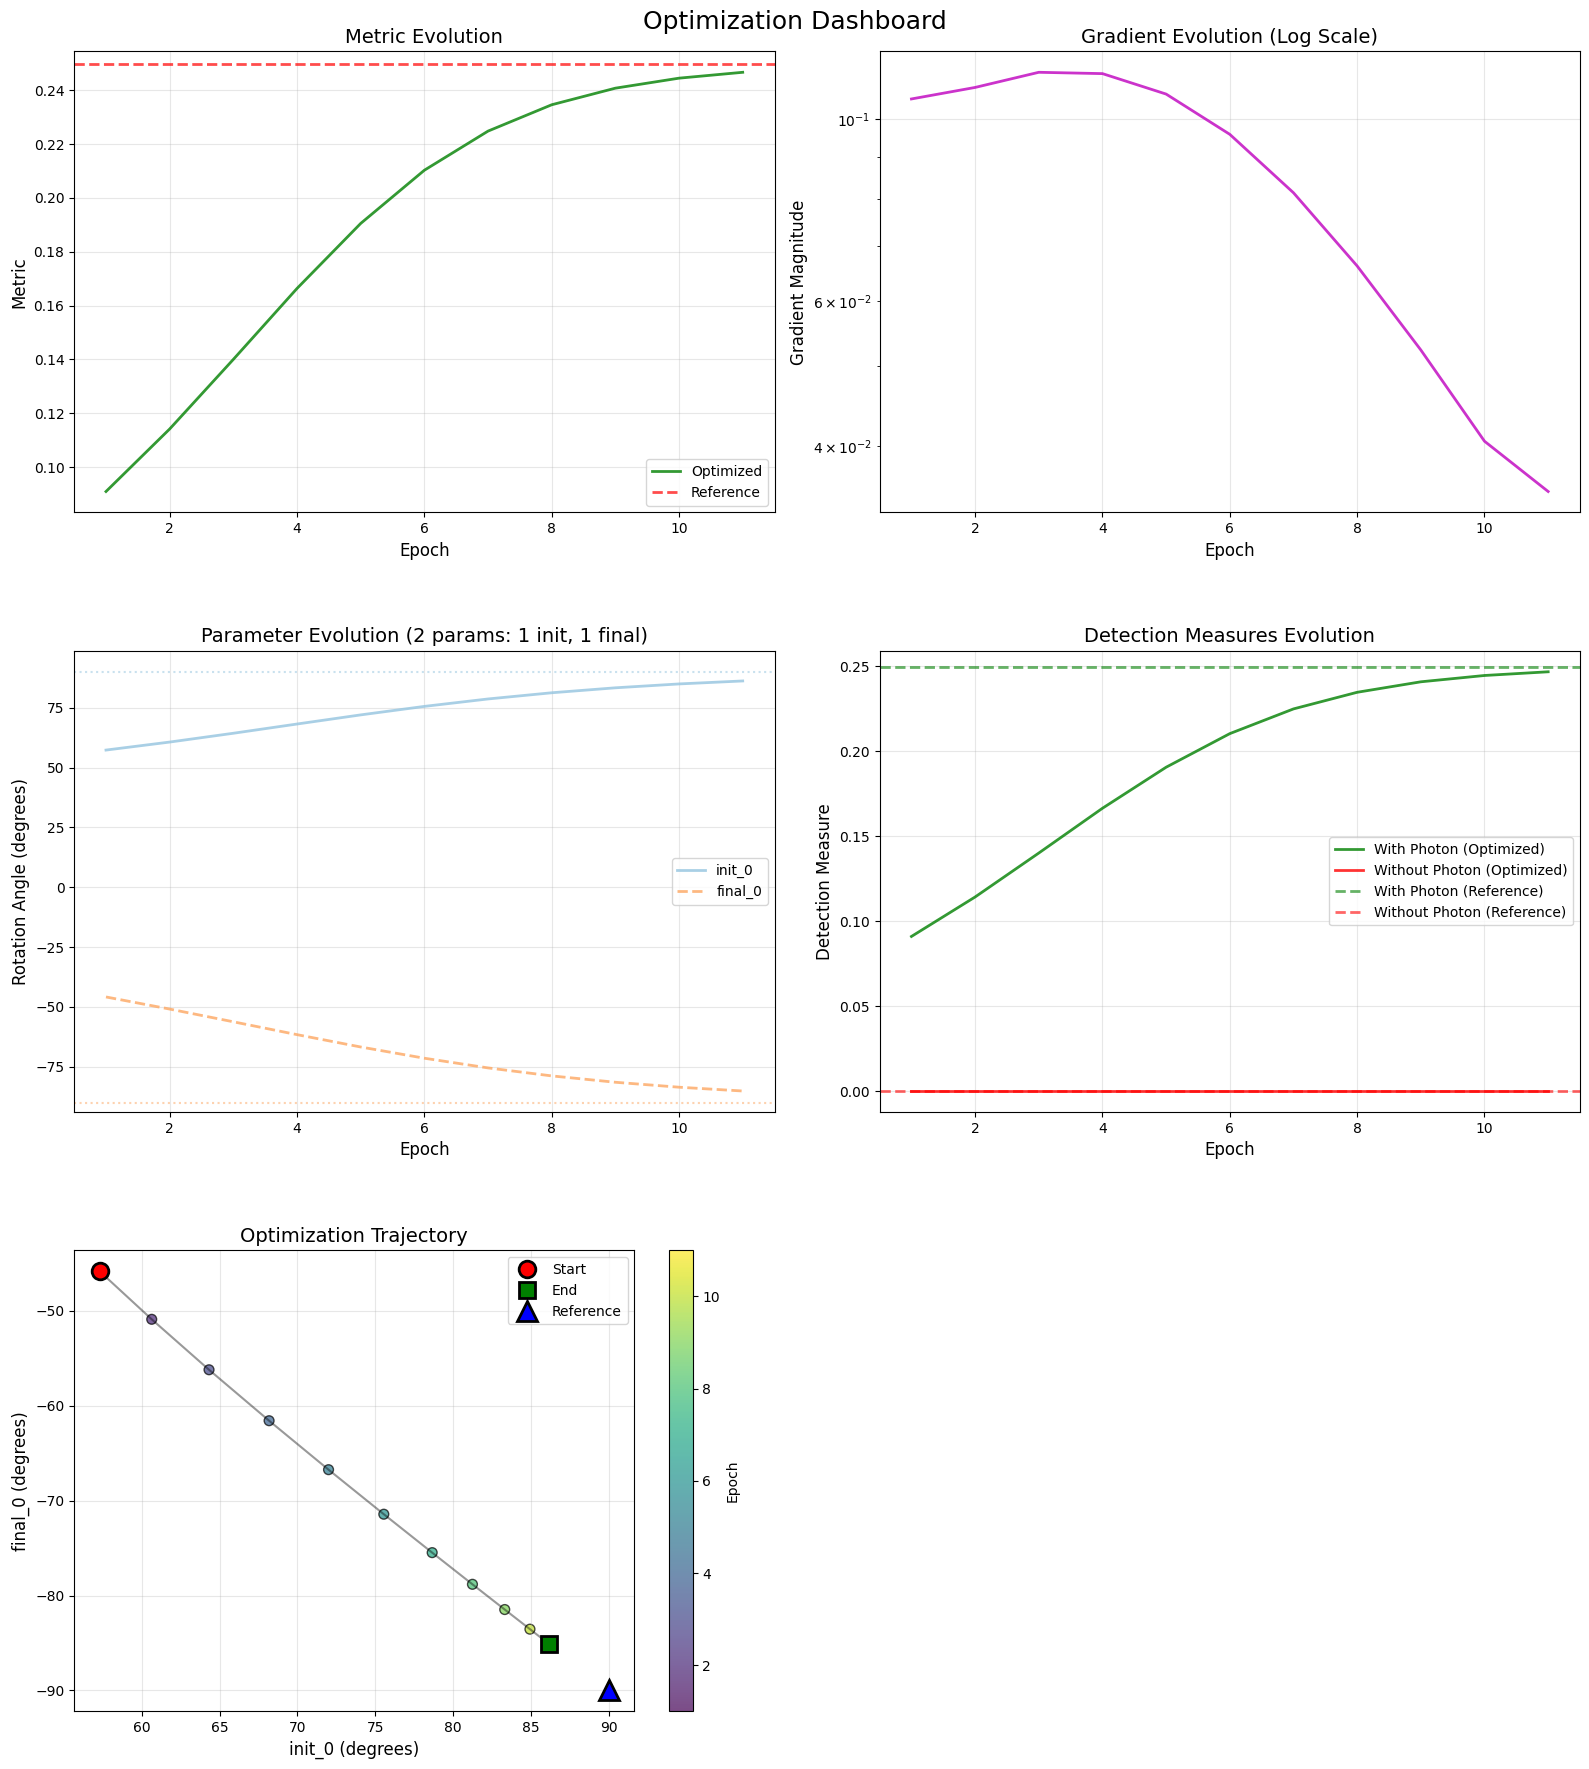

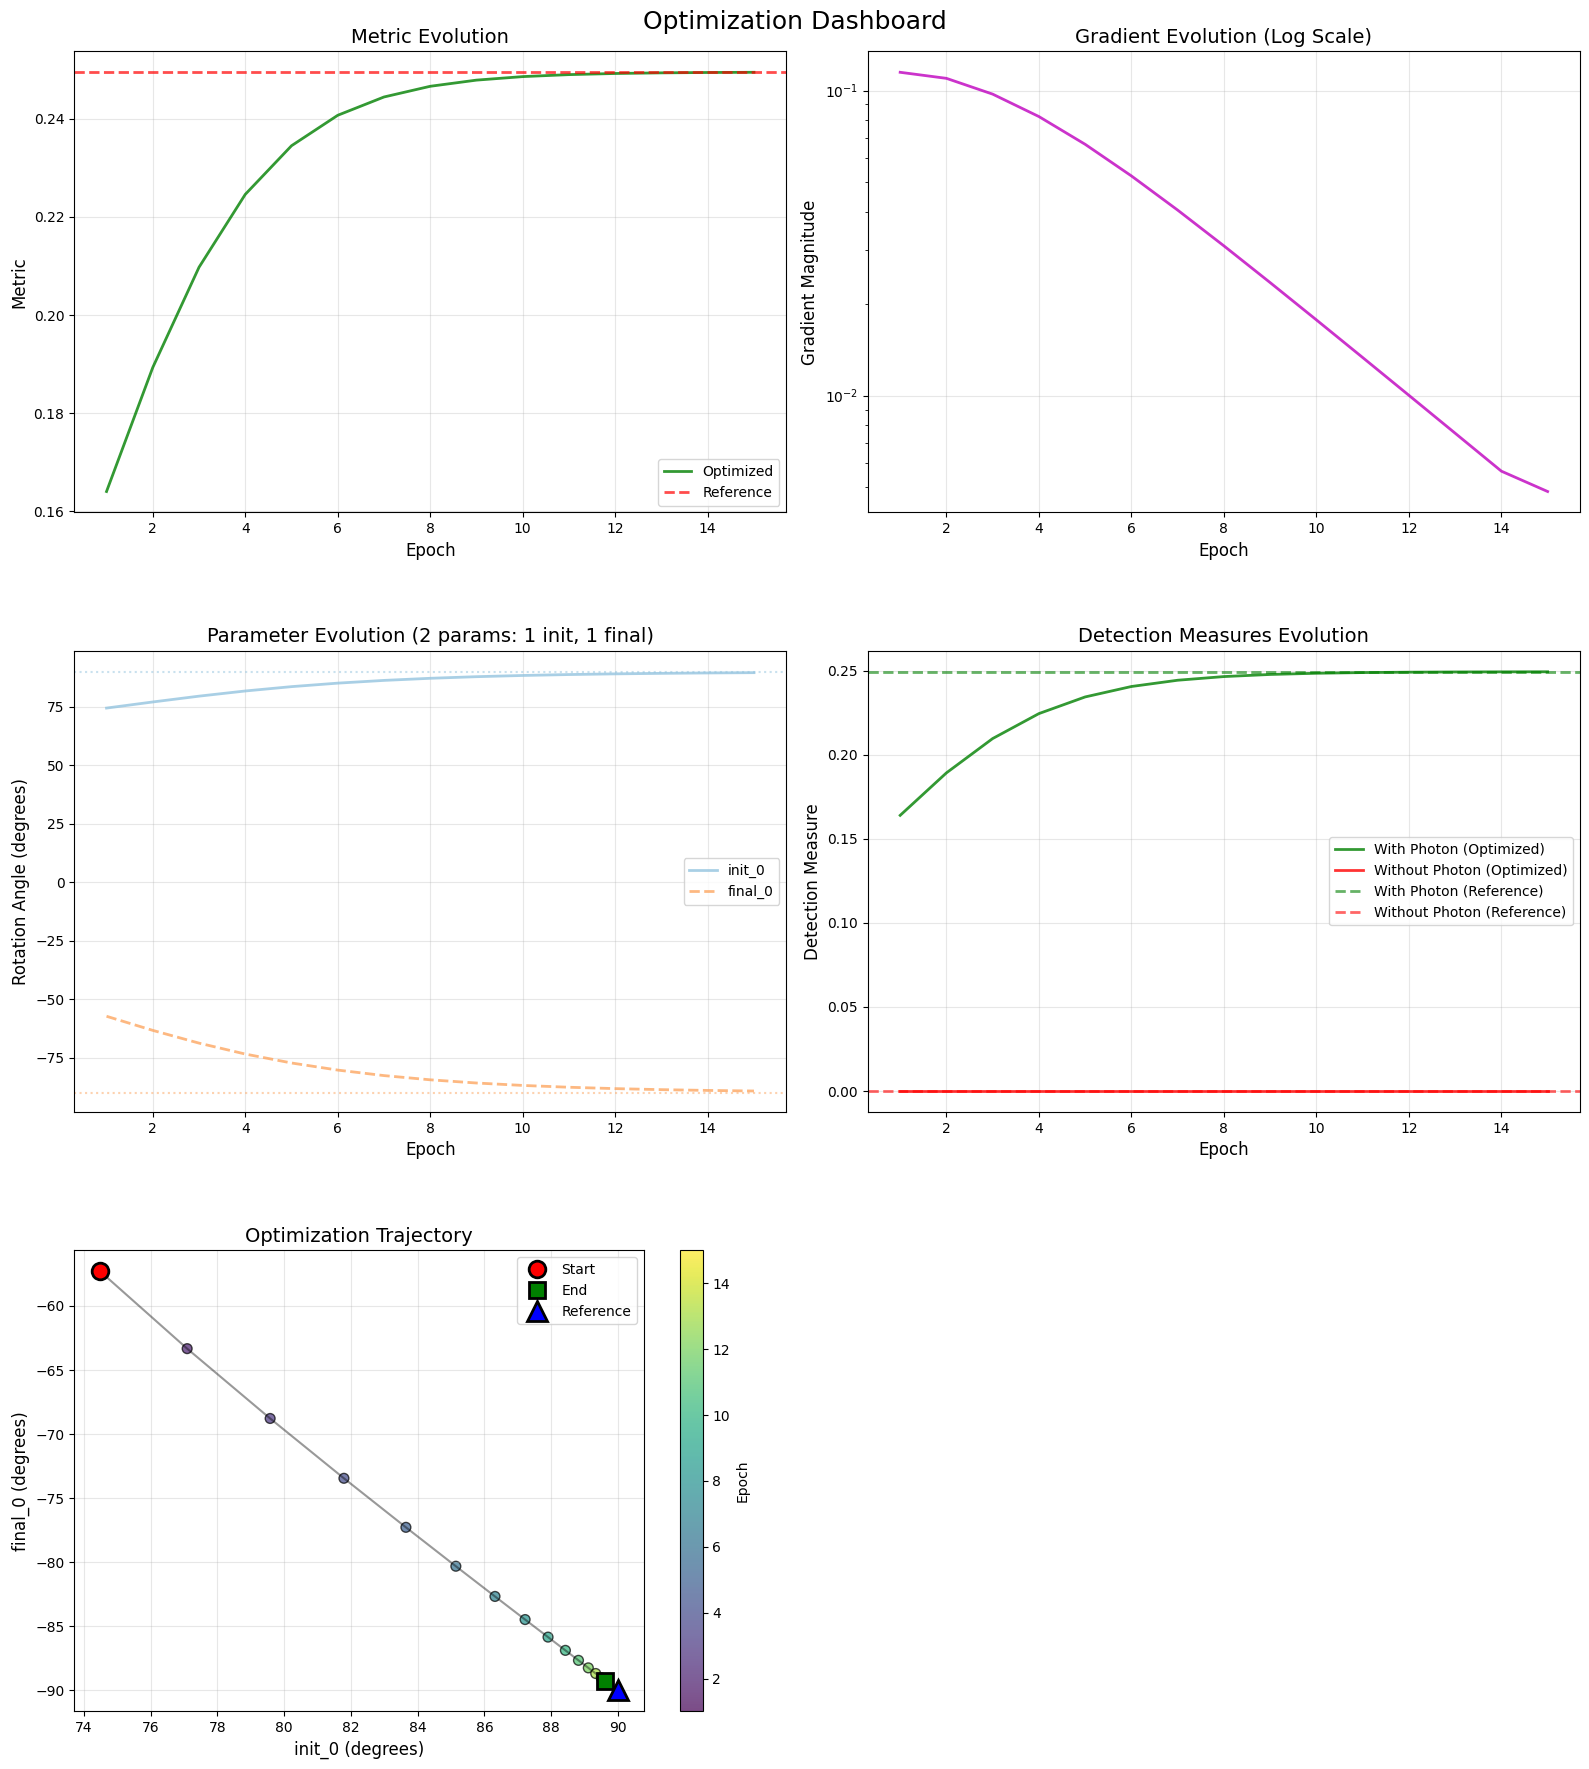

In [26]:
# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_resumed,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_continued,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

In [27]:
import numpy as np

res_epochs = np.array(history_resumed.history.get('epochs', []), dtype=int)
res_metric = np.array(history_resumed.history.get('metric', []), dtype=float)

cont_epochs = np.array(history_continued.history.get('epochs', []), dtype=int)
cont_metric = np.array(history_continued.history.get('metric', []), dtype=float)

print('resumed_epochs:', res_epochs.tolist())
print('resumed_metric:', res_metric.tolist())
print('continued_epochs:', cont_epochs.tolist())
print('continued_metric:', cont_metric.tolist())

n = min(len(res_metric), len(cont_metric))
print('overlap_len:', n)
if n > 0:
    diffs = np.abs(res_metric[:n] - cont_metric[:n])
    print('overlap_abs_diff:', diffs.tolist())
    print('max_abs_diff_overlap:', float(np.max(diffs)))

print('history_epochs:', history.history.get('epochs', []))
print('history_metric:', history.history.get('metric', []))

resumed_epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
resumed_metric: [0.0909272104162678, 0.11414998689462377, 0.13999941889759587, 0.1663444962236866, 0.1904924359307121, 0.21025421598660235, 0.22478889301322752, 0.23457212167406044, 0.2407383980558907, 0.24445613723005905, 0.24663562129307437]
continued_epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
continued_metric: [0.1640515203773838, 0.189331389856259, 0.20975634462542145, 0.22461013282338269, 0.2345212691490359, 0.24073031304102932, 0.24445920180629233, 0.24663999264348968, 0.2478952159263023, 0.24861098593428863, 0.2490169534953448, 0.2492465036242797, 0.2493760747945227, 0.24944914024626894, 0.24949031913757108]
overlap_len: 11
overlap_abs_diff: [0.07312430996111599, 0.07518140296163522, 0.06975692572782557, 0.05826563659969608, 0.04402883321832379, 0.03047609705442697, 0.019670308793064806, 0.01206787096942924, 0.007156817870411586, 0.00415484870422958, 0.0023813322022704364]
max_abs_diff_overlap: 0.07518140296163